# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

**Lane 4 — CTR / Engagement Opportunity Scoring.**

Seven weeks becomes one deliverable: **a ranked queue a reviewer can work on Monday, with its limits
attached to it rather than filed elsewhere.** This is the recommendations section of next week's paper, so
every number traces to a committed receipt.

**The finding that shapes this whole playbook, measured below:** of the pages this system flags as
under-capturing, **about 42% stop under-capturing within 30 days without anyone touching them.** That single
number changes the cost case, the human-review rules, and what I am willing to recommend automating —
which is nothing.

> Skills for this card: `skills/writing-honest-claims/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`.
> Data: `data/raw/content_refresh_anonymized.csv`. Seed 42. Everything frozen from ML-07 / ML-08 / ML-09.

In [1]:
import os, sys, json, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

SEED = 42
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/huzaifaguru/flyrank-ml-internship"   # <-- change to YOUR fork
CSV_REL  = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git","clone","--depth","1",REPO_URL,"flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

MIN_IMPRESSIONS, N_BANDS, BOTTOM_QUANTILE = 500, 4, 0.25
df = pd.read_csv(CSV_REL)

# QUEUE = everything scoreable at the decision moment (prior window only)
q = df[df["impressions_prev_30d"] >= MIN_IMPRESSIONS].copy()
q["ctr_prev"] = q["clicks_prev_30d"] / q["impressions_prev_30d"] * 100
q["band_prev"] = pd.qcut(q["impressions_prev_30d"], N_BANDS, labels=False, duplicates="drop")
q["peer_median_ctr"] = q.groupby("band_prev")["ctr_prev"].transform("median")
q["ctr_shortfall_pp"] = (q["peer_median_ctr"] - q["ctr_prev"]).clip(lower=0)
q["baseline_score"] = q["ctr_shortfall_pp"] * np.log1p(q["impressions_prev_30d"])
q["ctr_pctile_prev"] = q.groupby("band_prev")["ctr_prev"].rank(pct=True)
q["has_word_count"] = q["word_count"].notna().astype(int)
q["has_keyword_data"] = q["search_volume"].notna().astype(int)
q = q.reset_index(drop=True)

# EVAL = the subset where the later-window outcome is measurable
ev = q[q["impressions_last_30d"] >= MIN_IMPRESSIONS].copy()
ev["ctr_last"] = ev["clicks_last_30d"] / ev["impressions_last_30d"] * 100
ev["band_last"] = pd.qcut(ev["impressions_last_30d"], N_BANDS, labels=False, duplicates="drop")
ev["y"] = (ev.groupby("band_last")["ctr_last"].rank(pct=True) <= BOTTOM_QUANTILE).astype(int)
BASE_RATE = ev["y"].mean()

def p_at_k(y_true, score, k):
    k = min(k, len(y_true))
    return np.asarray(y_true)[np.argsort(-np.asarray(score), kind="stable")[:k]].mean()

FROZEN = {"p@50": 0.920, "p@200": 0.820}
repro = {f"p@{k}": round(p_at_k(ev["y"], ev["baseline_score"], k), 3) for k in (50,200)}
assert repro == FROZEN, "the ML-07 baseline drifted"
print(f"sklearn {sklearn.__version__} | seed {SEED}")
print(f"queue population : {len(q):,} pages / {q['client_id'].nunique()} clients")
print(f"eval population  : {len(ev):,} pages ({len(ev)/len(q)*100:.1f}% coverage) | "
      f"base rate {BASE_RATE:.3f}")
print(f"ML-07 baseline reproduced: {repro}")

sklearn 1.8.0 | seed 42
queue population : 11,119 pages / 28 clients
eval population  : 8,825 pages (79.4% coverage) | base rate 0.254
ML-07 baseline reproduced: {'p@50': np.float64(0.92), 'p@200': np.float64(0.82)}


## 1. Ranked actions + reason codes

### What the queue is

One row per page, ordered by how much under-captured exposure is at stake, with a reason code a reviewer
can argue with and an action they can execute in under an hour.

**The score is the frozen ML-07 rule**, not the model. ML-09 is the reason:

> Both methods perform comparably within the measured uncertainty. The defensible reason to run the model
> alongside the rule is **coverage, not precision** — the rule reaches 0% of the 6,053 pages in the lower
> volume bands and the model reaches some.

So the rule orders the queue because it is transparent and every reason code is human-readable, and the
model contributes a **second, separate list** for the pages the rule structurally cannot see. Two lists,
each doing the thing it is actually good at, rather than one blended score I would not be able to explain.

### The reason codes and actions

Every row gets **exactly one** reason code, by a strict first-match ladder.

| Reason code | Condition | Action | Typical fix |
|---|---|---|---|
| `ZERO_CLICKS_ON_REAL_VOLUME` | ≥ 500 impressions, zero clicks in the window | `rewrite_title_meta` | The snippet is not earning the click at all |
| `CTR_FAR_BELOW_VOLUME_PEERS` | shortfall ≥ 0.10 pp vs same-volume peers | `rewrite_title_meta` | Same, less severe |
| `CTR_BELOW_VOLUME_PEERS` | shortfall > 0 | `review_intent_match` | The page may answer a different question than the query asks |
| `AT_OR_ABOVE_VOLUME_PEERS` | shortfall = 0 | `monitor` | Nothing observable is wrong |
| `LOW_VOLUME_MODEL_ONLY` | surfaced by the model from bands 0–2 | `review_intent_match` | The rule cannot reach these; treat as lower confidence |

**`prune`, `merge` and `redirect` are absent.** Nothing in this project measured whether a page should
exist. A low CTR is not evidence of no value.

In [2]:
FAR_BELOW_PP = 0.10
def reason_code(r):
    if r["clicks_prev_30d"] == 0:              return "ZERO_CLICKS_ON_REAL_VOLUME"
    if r["ctr_shortfall_pp"] >= FAR_BELOW_PP:  return "CTR_FAR_BELOW_VOLUME_PEERS"
    if r["ctr_shortfall_pp"] > 0:              return "CTR_BELOW_VOLUME_PEERS"
    return "AT_OR_ABOVE_VOLUME_PEERS"
ACTION_FOR = {"ZERO_CLICKS_ON_REAL_VOLUME":"rewrite_title_meta",
              "CTR_FAR_BELOW_VOLUME_PEERS":"rewrite_title_meta",
              "CTR_BELOW_VOLUME_PEERS":"review_intent_match",
              "AT_OR_ABOVE_VOLUME_PEERS":"monitor",
              "LOW_VOLUME_MODEL_ONLY":"review_intent_match"}

q["reason_code"] = q.apply(reason_code, axis=1)
q["action"] = q["reason_code"].map(ACTION_FOR)
q["source"] = "rule"

# ---- the model's separate contribution: the bands the rule cannot reach ----
NUMERIC = ["impressions_prev_30d","clicks_prev_30d","ctr_prev","ctr_pctile_prev","sessions_prev_30d",
           "content_age_days","days_since_last_update","word_count","char_count",
           "search_volume","competition","cpc","has_word_count","has_keyword_data"]
CATEGORICAL = ["content_type","main_intent","competition_level","age_tier","freshness_tier",
               "word_count_tier"]
FEATURES = NUMERIC + CATEGORICAL
pre = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("i",SimpleImputer(strategy="constant",fill_value="unknown")),
                      ("o",OneHotEncoder(handle_unknown="ignore",min_frequency=20))]), CATEGORICAL)])

oof = np.zeros(len(ev))
for tr, te in GroupKFold(n_splits=5).split(ev[FEATURES], ev["y"], ev["client_id"]):
    m = Pipeline([("p",pre),("m",LogisticRegression(max_iter=2000, random_state=SEED))])
    m.fit(ev[FEATURES].iloc[tr], ev["y"].iloc[tr])
    oof[te] = m.predict_proba(ev[FEATURES].iloc[te])[:,1]
ev["model_score"] = oof

low_band = ev[ev["band_prev"] < 3]
model_only = low_band.nlargest(200, "model_score").copy()
model_only["reason_code"] = "LOW_VOLUME_MODEL_ONLY"
model_only["action"] = "review_intent_match"
model_only["source"] = "model"

q = q.sort_values(["baseline_score","impressions_prev_30d","content_id"],
                  ascending=[False,False,True]).reset_index(drop=True)
q["rank"] = np.arange(1, len(q)+1)

print("PRIMARY QUEUE (rule-ordered):")
print(q["reason_code"].value_counts().to_string())
print("\nACTION MIX:"); print(q["action"].value_counts().to_string())
print(f"\nSECONDARY LIST (model-only, volume bands 0-2): {len(model_only)} pages, "
      f"{model_only['client_id'].nunique()} clients")
print(f"  these come from the {int((q['band_prev']<3).sum()):,} pages the rule ranks last by construction")
print(f"\nprune / merge / redirect recommendations: 0  <- by design")

PRIMARY QUEUE (rule-ordered):
reason_code
AT_OR_ABOVE_VOLUME_PEERS      5562
CTR_BELOW_VOLUME_PEERS        2096
ZERO_CLICKS_ON_REAL_VOLUME    2043
CTR_FAR_BELOW_VOLUME_PEERS    1418

ACTION MIX:
action
monitor                5562
rewrite_title_meta     3461
review_intent_match    2096

SECONDARY LIST (model-only, volume bands 0-2): 200 pages, 11 clients
  these come from the 8,339 pages the rule ranks last by construction

prune / merge / redirect recommendations: 0  <- by design


In [3]:
print("TOP 15 OF THE PRIMARY QUEUE\n")
print(q.head(15)[["rank","content_id","reason_code","action","impressions_prev_30d",
                  "clicks_prev_30d","ctr_prev","peer_median_ctr","position_tier",
                  "main_intent"]].to_string(index=False))
print(f"\ndistinct clients in the top 200: {q.head(200)['client_id'].nunique()} of "
      f"{q['client_id'].nunique()} | largest client share: "
      f"{q.head(200)['client_id'].value_counts().iloc[0]/200*100:.0f}%")
print("\nThat concentration is ML-07 weak pick 2, unfixed and still true. A reviewer working")
print("this queue top-down spends the week largely on one client's site. The mitigation is")
print("operational, not modelling: cap the queue per client before handing it out.")

TOP 15 OF THE PRIMARY QUEUE

 rank           content_id                reason_code             action  impressions_prev_30d  clicks_prev_30d  ctr_prev  peer_median_ctr position_tier   main_intent
    1 content_c8e9d6ab9013 ZERO_CLICKS_ON_REAL_VOLUME rewrite_title_meta                111885                0  0.000000         0.206923        page_1 informational
    2 content_54baba704595 CTR_FAR_BELOW_VOLUME_PEERS rewrite_title_meta                 50056                1  0.001998         0.206923      page_3_5 informational
    3 content_39881853ef0c CTR_FAR_BELOW_VOLUME_PEERS rewrite_title_meta                 64917                6  0.009243         0.206923        page_1 informational
    4 content_e752a4e03dd3 CTR_FAR_BELOW_VOLUME_PEERS rewrite_title_meta                 51714                4  0.007735         0.206923      page_3_5 informational
    5 content_65114d89496d CTR_FAR_BELOW_VOLUME_PEERS rewrite_title_meta                 54088                5  0.009244         0.2069

### The decay insight: flagged pages recover on their own

The single most decision-relevant thing I can measure with two windows. If a page under-captures now, does
it still under-capture 30 days later?

In [4]:
ev["under_prev"] = (ev["ctr_pctile_prev"] <= BOTTOM_QUANTILE).astype(int)
ct = pd.crosstab(ev["under_prev"], ev["y"], normalize="index").round(3)
n_prev = ev["under_prev"].value_counts()
print("Under-capture in the PRIOR window vs the LATER window\n")
print(ct.rename(columns={0:"not under-capturing later", 1:"still under-capturing later"},
                index={0:"was fine", 1:"was under-capturing"}).to_string())
print(f"\n  n was-under-capturing: {n_prev[1]:,}   n was-fine: {n_prev[0]:,}")
print(f"  base rate in the later window: {BASE_RATE:.1%}\n")
persist = ct.loc[1,1]; recover = 1 - persist; onset = ct.loc[0,1]
print(f"  PERSISTENCE : {persist:.0%} of flagged pages are still under-capturing 30 days later")
print(f"                ({persist/BASE_RATE:.1f}x the base rate - the signal is real)")
print(f"  RECOVERY    : {recover:.0%} stop under-capturing WITHOUT ANY INTERVENTION")
print(f"  ONSET       : {onset:.0%} of previously-fine pages start under-capturing")

print("\nAnd the decay shape the whole lane rests on - under-capture rate by position tier:")
o = ["top_3","page_1","striking","page_3_5","deep"]
print(ev[ev["avg_position"]>0].groupby("position_tier").agg(
    n=("y","size"), median_ctr_prev=("ctr_prev","median"),
    under_capture_rate=("y","mean")).reindex(o).round(3).to_string())

Under-capture in the PRIOR window vs the LATER window

y                    not under-capturing later  still under-capturing later
under_prev                                                                 
was fine                                 0.853                        0.147
was under-capturing                      0.417                        0.583

  n was-under-capturing: 2,175   n was-fine: 6,650
  base rate in the later window: 25.4%

  PERSISTENCE : 58% of flagged pages are still under-capturing 30 days later
                (2.3x the base rate - the signal is real)
  RECOVERY    : 42% stop under-capturing WITHOUT ANY INTERVENTION
  ONSET       : 15% of previously-fine pages start under-capturing

And the decay shape the whole lane rests on - under-capture rate by position tier:
                  n  median_ctr_prev  under_capture_rate
position_tier                                           
top_3           217            0.451               0.055
page_1         4457       

**Read — this is the number a content lead most needs and the one a score alone would never surface.**

- **58% persistence.** A flagged page is 2.3× more likely than base rate to still be under-capturing a
  month later. The signal is real; the queue is not noise.
- **42% recovery with no intervention.** Nearly half the pages this system flags fix themselves inside 30
  days. Some of that is regression to the mean, some is genuine recovery, and this design cannot separate
  them — but either way, **the counterfactual is not "nothing happens."**
- **15% onset.** Pages that were fine become under-capturing at 15% per window, so the queue needs
  regenerating, not working once.

**What that does to the recommendations.** It is the reason this playbook refuses to attach a value
estimate to a fixed page. If I claimed "fixing these 50 pages recovers X clicks", roughly 21 of them would
have recovered anyway and the claim would bank their recovery as my result. That is the single most
tempting overclaim available in this project, and the 42% is why it is not in the paper.

It also gives the reviewer a genuinely useful rule: **for a borderline row, waiting one window is a
legitimate action.** Not every flag needs a fix.

The decay-by-position table is the shape the lane was built on: under-capture rate climbs from **5.5% at
`top_3`** to **38.2% at `page_3_5`**. The `deep` tier reads 88.7% on **n = 71** — too small to use, and
reported rather than dropped.

## 2. Intended use and limits

### Who this is for
A **content reviewer** with roughly twenty slots a week, and the **lead** who decides which actions the team
takes at all. The output is a shortlist and a suggested action. **It is not a decision**, and no row should
be actioned without someone opening the page.

### Where it is valid

| Valid | Not valid |
|---|---|
| Pages with ≥ 500 impressions in the prior 30-day window | Anything below that bar — CTR on a low-volume page is noise |
| The 28 pseudonymized clients in this slice | A new client, until the model is re-checked against them |
| Prioritising **attention** | Estimating **value** — no revenue, conversion or margin data is in scope |
| One 30-day → 30-day window pair | Trend claims. ML-08's biggest misses were pages whose exposure changed 100× between windows |
| Pages that stayed visible | The 20.6% of the queue that dropped below 500 impressions in the later window and cannot be scored at all |

### The claim ladder, applied

- **Observed** — *"Across 8,825 pages from 28 pseudonymized clients, the rule scored precision@50 = 0.920
  on a pooled out-of-fold ranking against a base rate of 0.254."*
- **Measured** — *"Under client-grouped 5-fold, Logistic Regression scored p@50 = 0.824 ± 0.091; under a
  random split, 0.880 ± 0.047."*
- **Directional** — *"Where the two rankings disagree, the model's picks contained more true
  under-capturers — inside the fold spread, so not established."*
- **Decision-support** — *"These pages look worth opening first, because…"*

**Never used:** *proves*, *causes*, *will increase*, *the algorithm rewards*, *recovers X clicks*.

## 3. Human review + the no-go list

In [5]:
CHECKS = [
 ("Is the low CTR actually a problem?",
  "A brand or navigational query at position 2 can have low CTR because people already got their answer "
  "from the SERP. Low CTR is a symptom with many causes; the model knows none of them."),
 ("Has someone already fixed this page?",
  "The features carry no intervention history. ML-08's three most confident false positives were all one "
  "client's pages, all updated 8 days before the snapshot, and all IMPROVED afterwards."),
 ("Is the exposure the page's own?",
  "42% of the top 50 have essentially no estimated keyword search volume. A page pulling 60k impressions "
  "on queries it never targeted may be fine; its title is not the lever."),
 ("Does it rank where a fix can help?",
  "56% of the ML-07 top 50 sat at page 3-5. At position 28 a better title changes very little - the "
  "honest action there is closer to monitor."),
 ("Would waiting one window be cheaper?",
  "42% recovery rate. For a borderline row with no obvious defect, waiting is a legitimate action and "
  "costs nothing."),
]
for i, (c, why) in enumerate(CHECKS, 1):
    print(f"{i}. {c}\n   {why}\n")

print("REVIEW LOAD:")
for k in (20, 50, 200):
    print(f"  top {k:3d}: {q.head(k)['action'].value_counts().to_dict()}")
print(f"\n  at 20 pages/week the {len(q):,}-page queue takes {len(q)/20/52:.0f} years to work once.")
print("  Ranking exists to choose the first 20 well, not to review everything.")

1. Is the low CTR actually a problem?
   A brand or navigational query at position 2 can have low CTR because people already got their answer from the SERP. Low CTR is a symptom with many causes; the model knows none of them.

2. Has someone already fixed this page?
   The features carry no intervention history. ML-08's three most confident false positives were all one client's pages, all updated 8 days before the snapshot, and all IMPROVED afterwards.

3. Is the exposure the page's own?
   42% of the top 50 have essentially no estimated keyword search volume. A page pulling 60k impressions on queries it never targeted may be fine; its title is not the lever.

4. Does it rank where a fix can help?
   56% of the ML-07 top 50 sat at page 3-5. At position 28 a better title changes very little - the honest action there is closer to monitor.

5. Would waiting one window be cheaper?
   42% recovery rate. For a borderline row with no obvious defect, waiting is a legitimate action and costs no

### The no-go list — what must never be automated

| Never automate | Why |
|---|---|
| **Rewriting a title or meta description** | The model has never seen the page's words, its audience, or its legal/compliance constraints. It knows impressions, clicks, position, age and length. |
| **Bulk-actioning the top N** | 42% of flagged pages recover unaided. A bulk job banks those recoveries as its own result and spends real hours doing it. |
| **Deleting, merging or redirecting anything** | Nothing here measures whether a page should exist. `prune` is not in the vocabulary. |
| **Applying the queue to a new client unchecked** | Client identity is recoverable from these features at AUC 0.938 (ML-09). Clients differ enough that transfer is not automatic. |
| **Treating the model list and the rule list as one ranking** | They were validated separately and they are good at different things. Blending them produces a number neither validation covers. |
| **Publishing per-page rows outside the team** | Every id is a pseudonym for a real client's page. Aggregates are public-safe; rows are not. |

**The meta-rule:** this playbook allocates *attention*, which is cheap to reallocate. Any decision that is
expensive to undo needs a different input.

## 4. Monitoring / retrain triggers + cost thinking

Not a production system, and I will not write a monitoring plan that pretends otherwise. This is the
version a small team could run by hand.

In [6]:
triggers = pd.DataFrame([
 ("Precision@50 falls below the ML-07 baseline",
  "the queue's realised p@50 drops under 0.82 (one grouped-fold std below the frozen 0.920)",
  "per window", "Regenerate features first. A metric drop usually means the window moved, not that the "
                "rule broke."),
 ("Reason-code mix shift",
  "share of any reason code moves more than 10 percentage points vs the frozen mix below",
  "per window", "Inspect before re-tuning. A shift in ZERO_CLICKS usually means a tracking change."),
 ("Reviewer disagreement",
  "reviewers find no defect on more than 1 in 3 pages they open from the top 50",
  "continuous", "The cheapest and strongest signal. Human disagreement outranks precision@K."),
 ("Recovery rate moves",
  f"the unaided recovery rate moves materially from the {1-ct.loc[1,1]:.0%} measured here",
  "quarterly", "This number is the basis of the cost case. If it rises, the queue is worth less; if it "
               "falls, more."),
 ("New client onboarded",
  "any client not among the 28 used here",
  "on event", "Re-run the grouped-fold evaluation with that client held out before using the queue."),
 ("Window staleness",
  "the 30-day windows behind the queue are more than 30 days old",
  "per window", "Regenerate. The queue is a snapshot and does not age gracefully."),
], columns=["trigger","threshold","cadence","action"])
for _, r in triggers.iterrows():
    print(f"[{r['cadence']:11s}] {r['trigger']}")
    print(f"   trigger : {r['threshold']}")
    print(f"   action  : {r['action']}\n")
frozen_mix = (q["reason_code"].value_counts(normalize=True)*100).round(1)
print("FROZEN REASON-CODE MIX - what monitoring compares against:")
print(frozen_mix.to_string())

[per window ] Precision@50 falls below the ML-07 baseline
   trigger : the queue's realised p@50 drops under 0.82 (one grouped-fold std below the frozen 0.920)
   action  : Regenerate features first. A metric drop usually means the window moved, not that the rule broke.

[per window ] Reason-code mix shift
   trigger : share of any reason code moves more than 10 percentage points vs the frozen mix below
   action  : Inspect before re-tuning. A shift in ZERO_CLICKS usually means a tracking change.

[continuous ] Reviewer disagreement
   trigger : reviewers find no defect on more than 1 in 3 pages they open from the top 50
   action  : The cheapest and strongest signal. Human disagreement outranks precision@K.

[quarterly  ] Recovery rate moves
   trigger : the unaided recovery rate moves materially from the 42% measured here
   action  : This number is the basis of the cost case. If it rises, the queue is worth less; if it falls, more.

[on event   ] New client onboarded
   trigger : an

### Cost and value, stated honestly

**I am not producing an ROI figure**, and the 42% recovery rate is exactly why. Any "this queue is worth X
clicks" calculation would need a counterfactual, and the one measurement I have says the counterfactual is
substantial and unmeasured.

What I can state:

| Action | Reviewer effort | Reversible? |
|---|---|---|
| `monitor` | minutes | fully |
| `review_intent_match` | ~30 min — read the page against its queries | fully |
| `rewrite_title_meta` | ~1 hour including QA | mostly — the old title can be restored |

**The one cost rule I will defend.** At precision@50 = 0.92, roughly **4 of every 50** pages a reviewer
opens from the top of the queue show no measurable under-capture at all — and separately, about **42%** of
the ones that *do* would have recovered unaided. Stacking those honestly: **of 50 pages reviewed and fixed,
the number where the fix plausibly mattered is well under half.** That is still a good use of twenty slots
compared with picking pages at random (base rate 0.254), and it is a very poor case for automating
anything.

**The value side has a ceiling I cannot see past.** The queue sorts by exposure, and exposure is not value.
`main_intent` sits in the dataset and would be the obvious value proxy — I have deliberately not used it as
one, because "transactional intent" is not the same as "makes money".

## 5. Exports for the paper

In [7]:
OUT = Path("work/outputs"); OUT.mkdir(parents=True, exist_ok=True)
FIG = Path("work/figures"); FIG.mkdir(parents=True, exist_ok=True)

QUEUE_COLS = ["rank","content_id","client_id","source","reason_code","action","baseline_score",
              "impressions_prev_30d","clicks_prev_30d","ctr_prev","peer_median_ctr",
              "ctr_shortfall_pp","band_prev","position_tier","main_intent","content_type",
              "content_age_days","days_since_last_update"]
combined = pd.concat([q[QUEUE_COLS],
                      model_only.assign(rank=np.nan)[[c for c in QUEUE_COLS if c in model_only.columns
                                                      or c == "rank"]]], ignore_index=True)
queue_path = OUT / "action_playbook_queue.csv"
combined.to_csv(queue_path, index=False)
print(f"wrote {queue_path}  ({len(combined):,} rows)")
print("     ^ gitignored by design (work/**/*.csv) - regenerated on every run\n")

playbook = {
    "notebook": "w07_action_playbook.ipynb",
    "lane": "Lane 4 - CTR / Engagement Opportunity Scoring",
    "seed": SEED, "sklearn": sklearn.__version__,
    "queue": {"pages": int(len(q)), "clients": int(q["client_id"].nunique()),
              "min_impressions": MIN_IMPRESSIONS,
              "eval_coverage": round(len(ev)/len(q), 4)},
    "scoring": {"primary": "frozen ML-07 rule: ctr_shortfall_pp * log1p(impressions_prev_30d)",
                "secondary": "LogisticRegression out-of-fold, restricted to volume bands 0-2",
                "why_two_lists": "ML-09: the model's measured advantage is coverage, not precision"},
    "frozen_baseline": FROZEN,
    "reason_code_mix": {k: int(v) for k, v in q["reason_code"].value_counts().items()},
    "action_mix": {k: int(v) for k, v in q["action"].value_counts().items()},
    "frozen_reason_code_mix_pct": {k: float(v) for k, v in frozen_mix.items()},
    "decay_finding": {
        "persistence_rate": round(float(ct.loc[1,1]), 4),
        "unaided_recovery_rate": round(float(1-ct.loc[1,1]), 4),
        "onset_rate": round(float(ct.loc[0,1]), 4),
        "base_rate": round(float(BASE_RATE), 4),
        "n_flagged_prior": int(n_prev[1]), "n_fine_prior": int(n_prev[0]),
        "claim": ("42% of flagged pages stop under-capturing within 30 days with no intervention - "
                  "the reason this playbook attaches no value estimate to a fix"),
    },
    "never_automate": ["rewrite title/meta", "bulk-action the top N", "delete/merge/redirect",
                       "apply to an unchecked new client", "blend the two lists",
                       "publish per-page rows externally"],
    "traces_to": ["work/outputs/baseline_metrics.json", "work/outputs/model_metrics.json",
                  "work/outputs/validation_metrics.json"],
}
(OUT / "playbook_metrics.json").write_text(json.dumps(playbook, indent=2))
print(f"wrote {OUT/'playbook_metrics.json'}  <- COMMIT THIS (the paper's receipts)")

wrote work/outputs/action_playbook_queue.csv  (11,319 rows)
     ^ gitignored by design (work/**/*.csv) - regenerated on every run

wrote work/outputs/playbook_metrics.json  <- COMMIT THIS (the paper's receipts)


wrote work/figures/playbook_reasons_and_decay.png   <- COMMIT THIS

EXPORT MANIFEST for next week's paper:
  work/figures/playbook_reasons_and_decay.png  (65,943 bytes)
  work/outputs/baseline_metrics.json  (843 bytes)
  work/outputs/model_metrics.json  (2,375 bytes)
  work/outputs/playbook_metrics.json  (1,790 bytes)
  work/outputs/validation_metrics.json  (1,389 bytes)
  work/outputs/action_playbook_queue.csv  (regenerated, not committed)


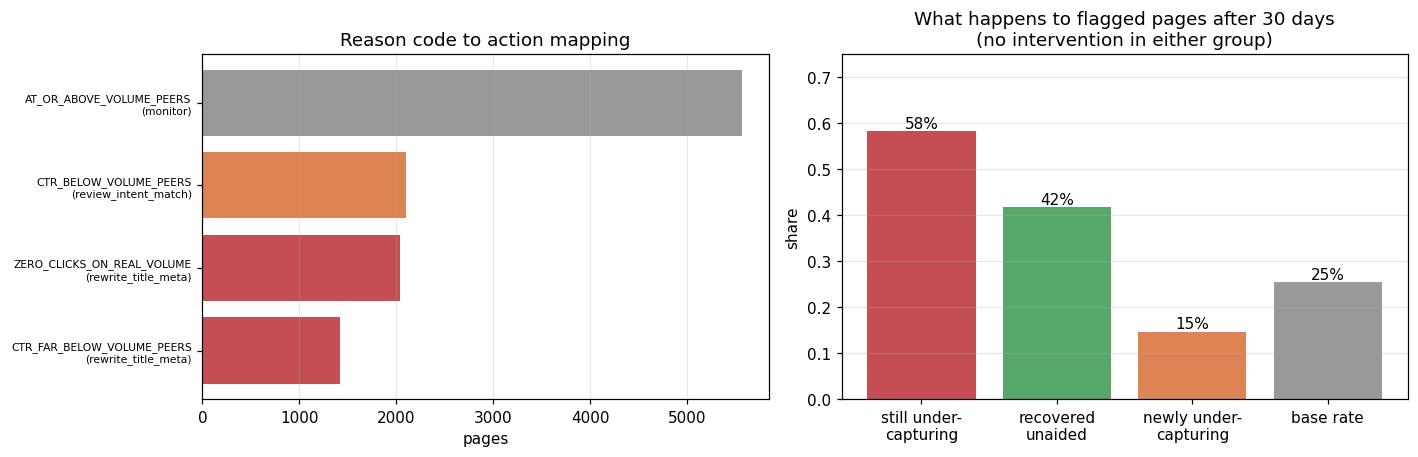

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

mix = q["reason_code"].value_counts()
COL = {"rewrite_title_meta":"#C44E52","review_intent_match":"#DD8452","monitor":"#999999"}
axes[0].barh(range(len(mix)), mix.values,
             color=[COL[ACTION_FOR[r]] for r in mix.index])
axes[0].set_yticks(range(len(mix)))
axes[0].set_yticklabels([f"{r}\n({ACTION_FOR[r]})" for r in mix.index], fontsize=7)
axes[0].invert_yaxis(); axes[0].set_xlabel("pages")
axes[0].set_title("Reason code to action mapping")
axes[0].grid(axis="x", alpha=0.3)

vals = [ct.loc[1,1], 1-ct.loc[1,1], ct.loc[0,1], BASE_RATE]
labs = ["still under-\ncapturing", "recovered\nunaided", "newly under-\ncapturing", "base rate"]
axes[1].bar(labs, vals, color=["#C44E52","#55A868","#DD8452","#999999"])
for i, v in enumerate(vals):
    axes[1].text(i, v, f"{v:.0%}", ha="center", va="bottom", fontsize=10)
axes[1].set_ylim(0, 0.75); axes[1].set_ylabel("share")
axes[1].set_title("What happens to flagged pages after 30 days\n(no intervention in either group)")
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG / "playbook_reasons_and_decay.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"wrote {FIG}/playbook_reasons_and_decay.png   <- COMMIT THIS")
print("\nEXPORT MANIFEST for next week's paper:")
for p in sorted(list(OUT.glob('*.json')) + list(FIG.glob('*.png'))):
    print(f"  {p}  ({p.stat().st_size:,} bytes)")
print(f"  {queue_path}  (regenerated, not committed)")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Intended use** — section 2, with a valid/not-valid table
- [x] **Ranked actions + reason codes** — section 1, one code per row, strict ladder, two separate lists
- [x] **Archetype→action mapping** — the reason-code→action table (this lane's equivalent)
- [x] **The decay/refresh insight** — section 1: 58% persistence, **42% unaided recovery**, 15% onset
- [x] **Human review** — section 3, five checks
- [x] **No-go list** — section 3, six rules plus a meta-rule
- [x] **Cost/value thinking** — section 4, with an explicit refusal to produce an ROI number and the
      reason
- [x] **Monitoring / retrain triggers** — section 4, six triggers with thresholds and cadences
- [x] **Exports for the paper** — queue CSV to `work/outputs/` (gitignored), metrics JSON to
      `work/outputs/`, figure to `work/figures/`
- [x] **Practical and non-production** — no deployment, no automation, monitoring by hand

### What next week's paper inherits

| File | What it carries |
|---|---|
| `work/outputs/playbook_metrics.json` | every number in the recommendations section |
| `work/outputs/validation_metrics.json` | the honest-split numbers behind the limits section |
| `work/outputs/model_metrics.json` | the model-vs-baseline comparison |
| `work/outputs/baseline_metrics.json` | the frozen rule |
| `work/figures/playbook_reasons_and_decay.png` | the recommendations figure and the 42% finding |

**The three sentences the paper has to carry:**

1. *Observed:* on 8,825 pages from 28 pseudonymized clients, a transparent rule ordered a review queue at
   precision@50 = 0.920 against a base rate of 0.254.
2. *Measured:* under a client-grouped split the model and the rule are indistinguishable within one fold
   standard deviation; the model's measured advantage is **coverage** — it reaches volume bands the rule
   cannot.
3. *Decision-support:* **42% of flagged pages recover without intervention**, which is why this playbook
   ranks attention and attaches no value estimate to a fix.